In [1]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures  # For the Counter function

In [2]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67137376

### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.33    # dispersal rate from release site to household
rho = 0.33     # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

rel_male = 1
rel_fem = 0

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relhhold"

"relhhold"

In [3]:
# Define parameters dictionary
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release
rel_size = 8 # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 25 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 8
  :gamma    => 0.33
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

In [4]:
### Convert dispersal parameters to a string and remove the decimal point
## We will use this to call the correct data files
rho_str = replace(string(rho), "." => "")
tau_str = replace(string(tau), "." => "")
gamma_str = replace(string(gamma), "." => "")
alpha_str = replace(string(alpha), "." => "")

"01"

In [26]:
## Read in the total wildtype and Wolbachia-infected mosquito populations data, 
## as well as free population only versions

df_m = CSV.read(joinpath("Initial_paper_results", "$(JOB_ID)", "$(JOB_ID)", "m_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).csv"), DataFrame)
df_w = CSV.read(joinpath("Initial_paper_results", "$(JOB_ID)", "$(JOB_ID)", "w_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).csv"), DataFrame)
m_array = Array(df_m) # convert to array
w_array = Array(df_w)
df_free_m = CSV.read(joinpath("Initial_paper_results", "$(JOB_ID)", "$(JOB_ID)", "free_m_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).csv"), DataFrame)
df_free_w = CSV.read(joinpath("Initial_paper_results", "$(JOB_ID)", "$(JOB_ID)", "free_w_mosqs_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).csv"), DataFrame)
free_m_array = Array(df_free_m)
free_w_array = Array(df_free_w)

1001×100 Matrix{Float64}:
   0.0  0.0    0.0    0.0    0.0  …  0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0  …  0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   0.0  0.0    0.0    0.0    0.0     0.0    0.0    0.0  0.0    0.0  0.0
   ⋮                              ⋱         ⋮                       
 190.0  0.0  229.0  191.0  238.0     0.0  221.0  169.0  0.0  112.0  0.0
 183.0  0.0  222.0  203.0  251.0     0.0  212.0  176.0  0.0  106.0  0.0
 174.0  0.0  254.0  191.0  234.0     0.0 

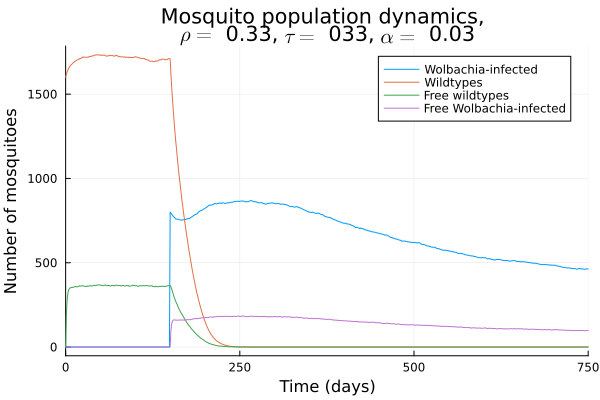

In [27]:
# Plot the data
p = plot(t_start:t_end, mean(w_array, dims=2), label="Wolbachia-infected")
plot!(t_start:t_end, mean(m_array, dims=2), label="Wildtypes")
#plot!(xlabel="Time (days)", ylabel="Number of mosquitoes", title="Mosquito population dynamics, 
#\$\\rho=\$ $rho, \$\\tau=\$ $tau, \$\\alpha=\$ $alpha", titlefont=font(14))
plot!(xlabel="Time (days)", ylabel="Number of mosquitoes", title="Mosquito population dynamics, 
\$\\rho=\$ $rho, \$\\tau=\$ $tau_str, \$\\alpha=\$ $alpha", titlefont=font(14)),# \$\\gamma=\$ $gamma
plot!(t_start:t_end, mean(free_m_array, dims=2), label="Free wildtypes")
plot!(t_start:t_end, mean(free_w_array, dims=2), label="Free Wolbachia-infected")
#vline!([170])
#plot!(legend=(0.7,0.7))
plot!(xlim=(0, 750))
#print("mosquito_population_dynamics_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).pdf")
savefig(p, "mosq_pop_dyn_males_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).pdf")
p

In [28]:
# Function to generate the file name
function generate_filename(type, i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size)
    return "$(type)_$(i)_$(alpha_str)_$(gamma_str)_$(rho_str)_$(tau_str)_$(H)__$(rel_t)_$(rel_size)_$(rel_type).csv"
end

# Function to check if the file exists and read it
function check_and_read_file(type, i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size)
    filename = generate_filename(type, i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size)
    if isfile(joinpath("sensitivity-anal", "$(JOB_ID)", "$(JOB_ID)",filename))
        println("File $filename exists. Reading the file.")
        df = CSV.read(joinpath("sensitivity-anal", "$(JOB_ID)", "$(JOB_ID)",filename), DataFrame)
        return df
    else
        println("File $filename does not exist.")
        return nothing
    end
end

# Initialize an array to accumulate the sum of arrays
sum_array = nothing
ct = 0

for i in 1:num_simulations
    df_f = check_and_read_file("fem_w_hholds", i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size)
    df_m = check_and_read_file("male_w_hholds", i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size)
    if df_f !== nothing && df_m !== nothing
        # Convert DataFrame to array
        arr_f = Matrix(df_f)
        arr_m = Matrix(df_m)
        sum = arr_f .+ arr_m
        
        # Accumulate the sum of arrays
        if sum_array === nothing
            sum_array = sum
        else
            sum_array .+= sum
        end
        ct += 1
    else
        println("DataFrame for simulation $i does not exist. Skipping.")
    end
end

# Compute the mean array
# this gives the mean over all sims for each household
if ct > 0
    mean_array = sum_array ./ ct
    println("Mean array computed successfully.")
else
    println("No valid data files found.")
end

File fem_w_hholds_1_003_015_033_033_100__150_8_relhhold.csv does not exist.
File male_w_hholds_1_003_015_033_033_100__150_8_relhhold.csv does not exist.
DataFrame for simulation 1 does not exist. Skipping.
File fem_w_hholds_2_003_015_033_033_100__150_8_relhhold.csv does not exist.
File male_w_hholds_2_003_015_033_033_100__150_8_relhhold.csv does not exist.
DataFrame for simulation 2 does not exist. Skipping.
File fem_w_hholds_3_003_015_033_033_100__150_8_relhhold.csv does not exist.
File male_w_hholds_3_003_015_033_033_100__150_8_relhhold.csv does not exist.
DataFrame for simulation 3 does not exist. Skipping.
File fem_w_hholds_4_003_015_033_033_100__150_8_relhhold.csv does not exist.
File male_w_hholds_4_003_015_033_033_100__150_8_relhhold.csv does not exist.
DataFrame for simulation 4 does not exist. Skipping.
File fem_w_hholds_5_003_015_033_033_100__150_8_relhhold.csv does not exist.
File male_w_hholds_5_003_015_033_033_100__150_8_relhhold.csv does not exist.
DataFrame for simulatio